# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [2]:
from Tools.DatasetTools.Commoms import *
dataset = 'Fe-Mo'  # 'Cr-Co-W'#'Fe-Mo/'
components = dataset.split('-')
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer  import Featurizer
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)


In [3]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

# Compositions 

# Population of phases

<AxesSubplot:xlabel='Phase', ylabel='Count'>

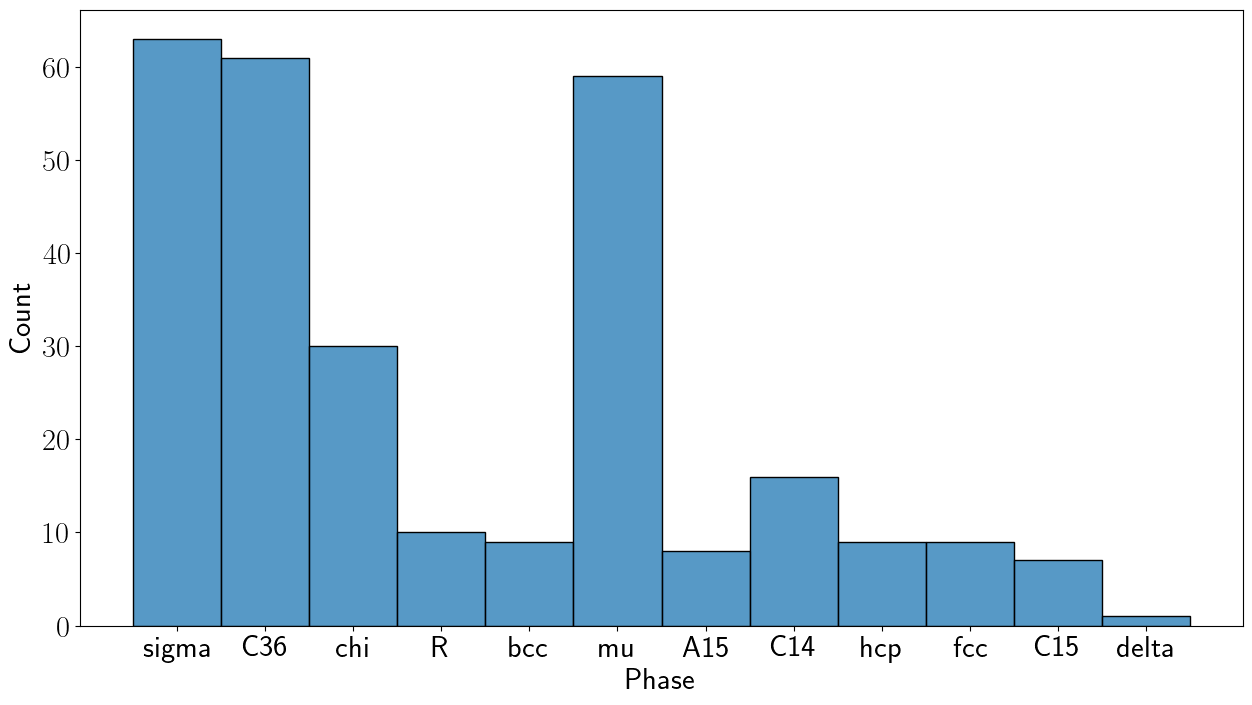

In [4]:
fig, ax = plt.subplots(figsize=(15,8))
# sns.histplot(x = BS['Phase'], ax=ax)
#ax.hist(BS['Phase'])
sns.histplot(x=BS['Phase'], ax=ax)

In [5]:
BS['Phase'].value_counts()

sigma    63
C36      61
mu       59
chi      30
C14      16
R        10
bcc       9
hcp       9
fcc       9
A15       8
C15       7
delta     1
Name: Phase, dtype: int64

## Remove samples with very little representation

In [6]:
BS = BS[BS['Phase'] != 'delta']

# Extra features 

In [7]:
Features = Featurizer(BS)

<AxesSubplot:ylabel='Count'>

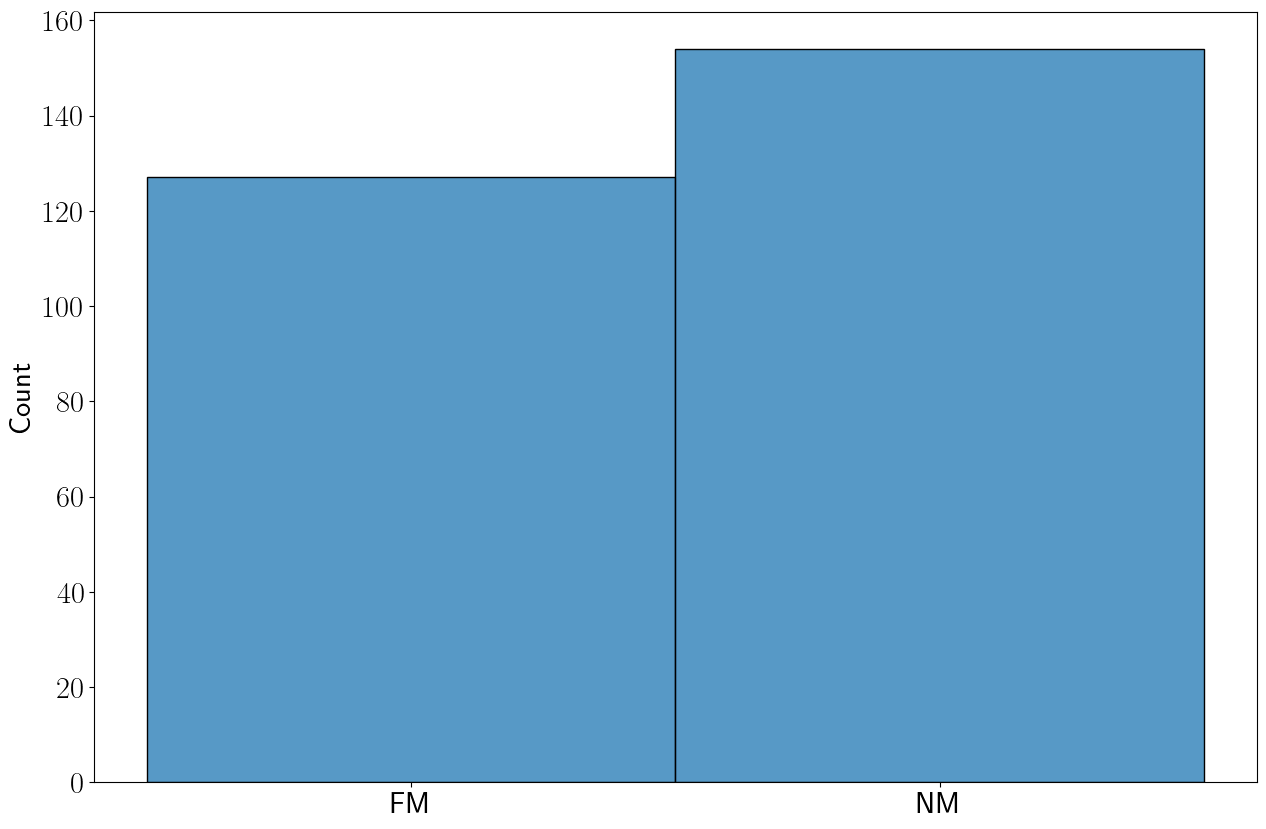

In [8]:
sns.histplot(x = Features.Mag)

In [9]:
isfm = Features.Mag.str.contains('FM')

In [10]:
fmsamples = BS.index[isfm]

In [11]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [12]:
nmsamples = BS.index[~isfm]

## fm samples without nm counterpart:

In [13]:
nmsamples.difference(fmsamplesasnm)

Index(['Fe_pv10Mo_sv14.C36-ABBBA.NM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv11Mo_sv2.mu-AAABA.NM', 'Fe_pv11Mo_sv2.mu-AABAA.NM',
       'Fe_pv13.mu.NM', 'Fe_pv13Mo_sv16.chi-ABAB.NM',
       'Fe_pv14Mo_sv16.sigma-AABAB.NM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv18Mo_sv6.C36-AAABA.NM', 'Fe_pv1Mo_sv1.L10-NiAl-AB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv28Mo_sv1.chi-BAAA.NM',
       'Fe_pv2Mo_sv2.B32-AB.NM', 'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM',
       'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM', 'Fe_pv3Mo_sv1.D03-A3B.NM',
       'Fe_pv3Mo_sv10.mu-ABBBA.NM', 'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM', 'Fe_pv53.R.NM',
       'Fe_pv5Mo_sv8.mu-ABBAA.NM', 'Fe_pv6.C15.NM',
       'Fe_pv6Mo_sv2.D0_19-A3B.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Mo_sv53.R.NM'],
      dtype='object')

## nm samples as without fm counterpart:

In [14]:
fmsamplesasnm.difference(nmsamples)

Index([], dtype='object')

#  Obvious outliers removal

In [15]:
BS = BS[(BS.B0 > 0 ) ]

In [16]:
minB0 = BS[BS['nelem']==1]['B0'].min()

In [17]:
maxB0 = BS[BS['nelem']==1]['B0'].max()

In [18]:
BS[BS['B0']>maxB0]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase


In [19]:
BS[BS['B0']<minB0]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase


# Distribution of Target Variables 

## total energy

In [20]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

In [21]:
if dataset == 'Cr-Co-W':
    BS = BS[(BS['E0']>-500) & (BS['V0']<40)]

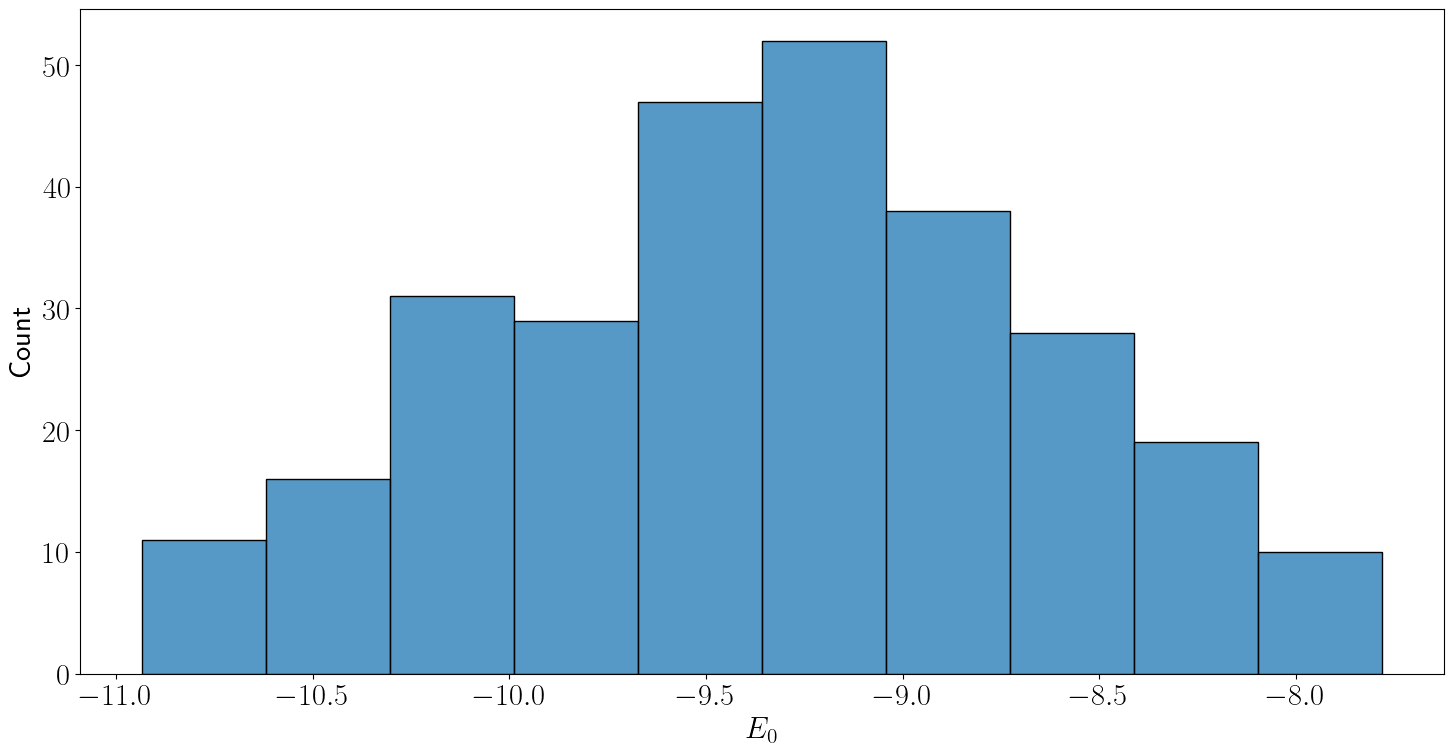

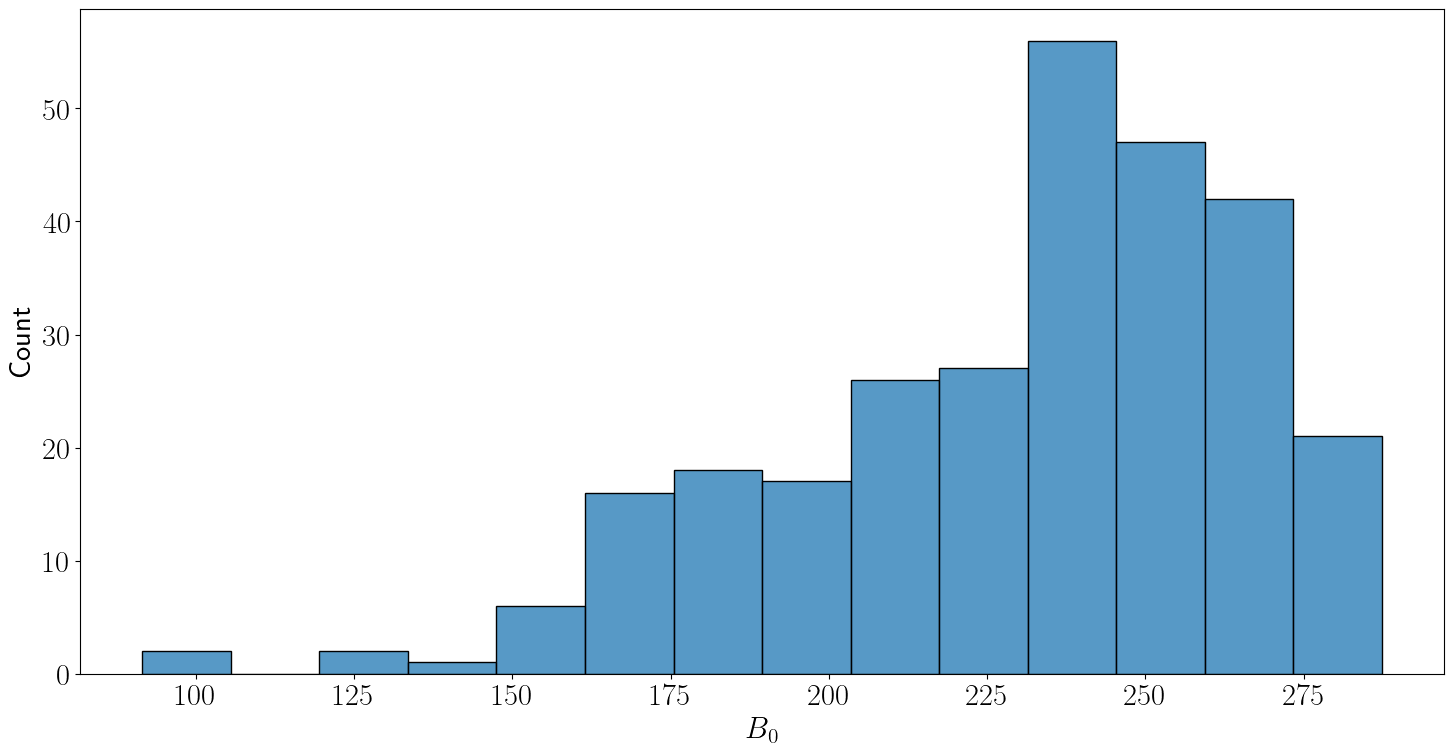

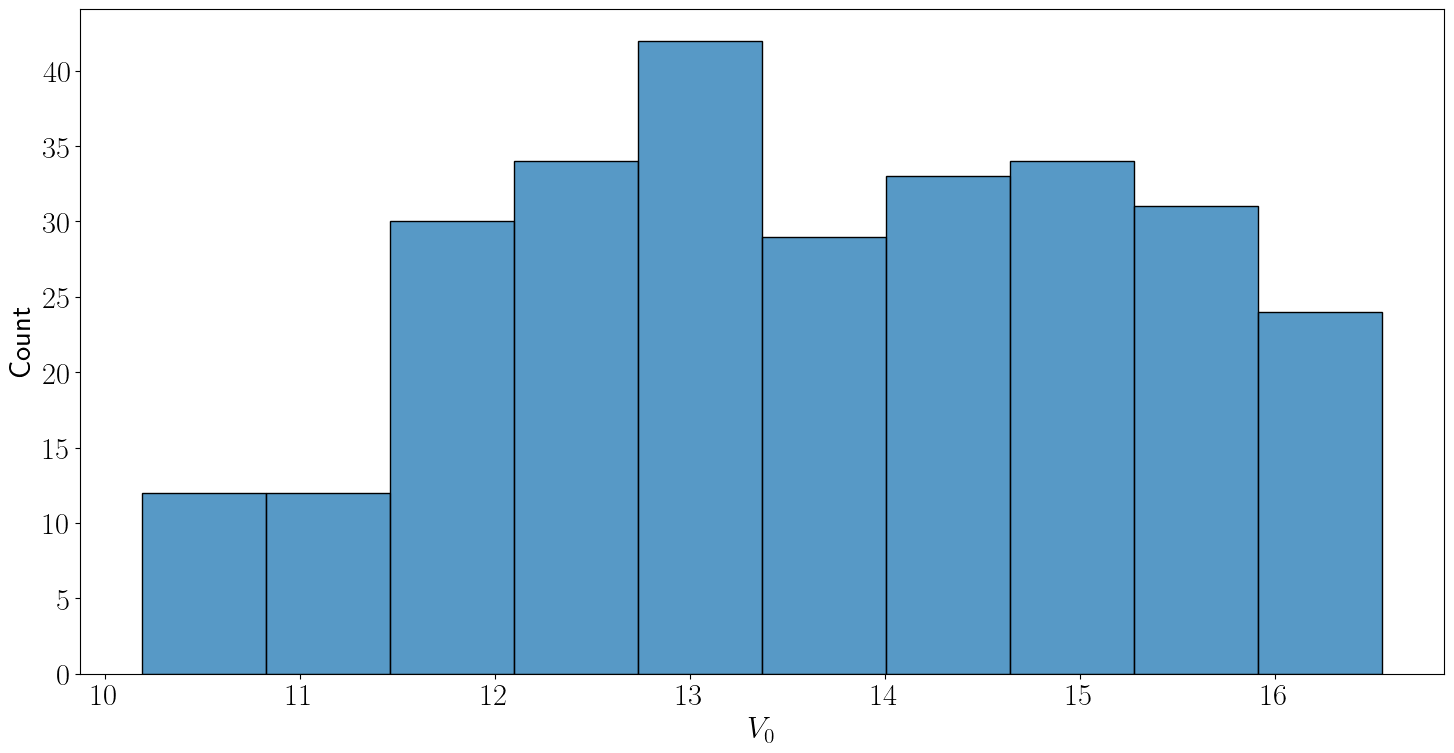

In [22]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [23]:
BS.sort_values(by='B0', inplace=True)

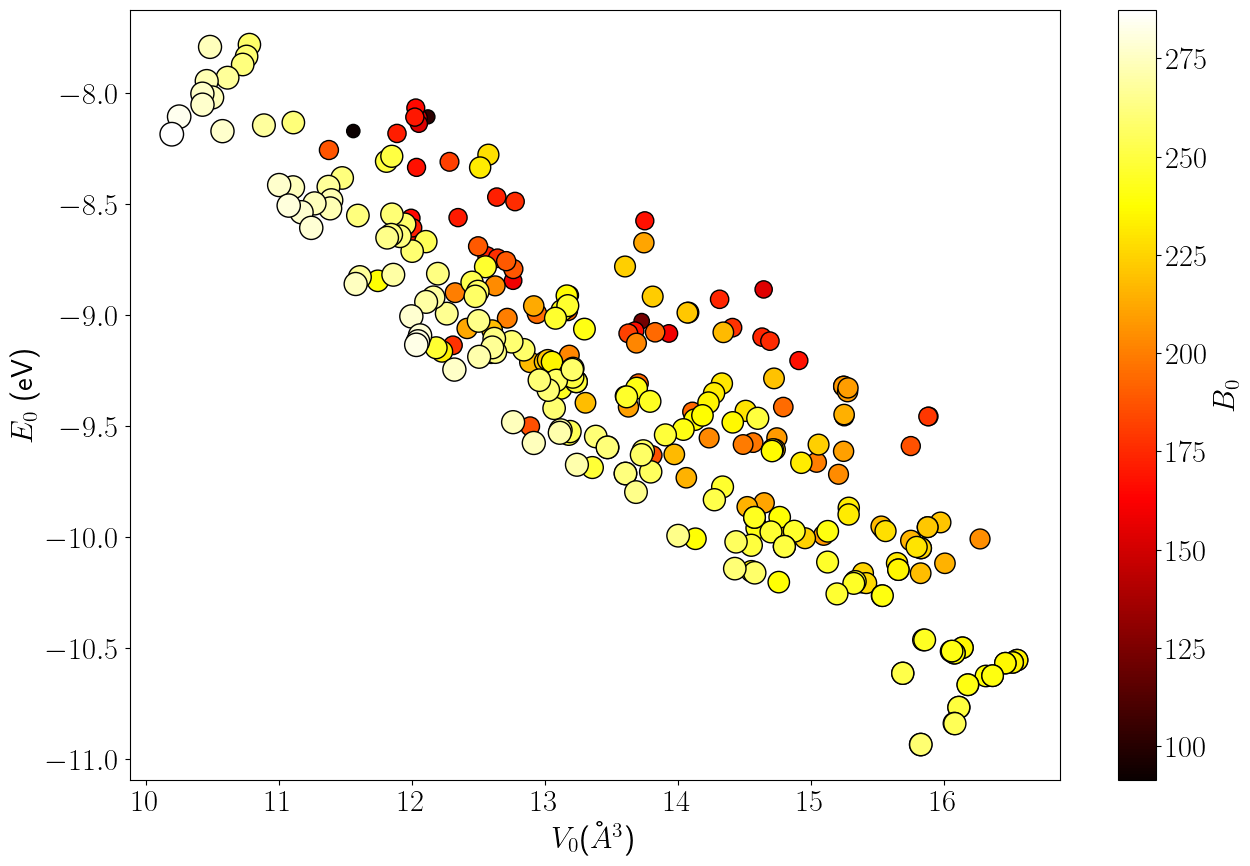

In [24]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['E0']+' (eV)')
plt.xlabel(targets['V0']+'($\AA^3$)')
cbar.set_label(targets['B0'])
#outlier_right = BS[(BS['E0']>-8) & (BS['V0']>14)].index
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )
#plt.annotate(outlier_right[0],*BS.loc[outlier_right][['V0', 'E0']].values,fontsize=16)
#outlier_high_b0 = BS[BS['B0']>1200].index
# plt.annotate(outlier_high_b0[0],*BS.loc[outlier_high_b0][['V0', 'E0']].values, fontsize=16)

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

# Pair Plots

In [25]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

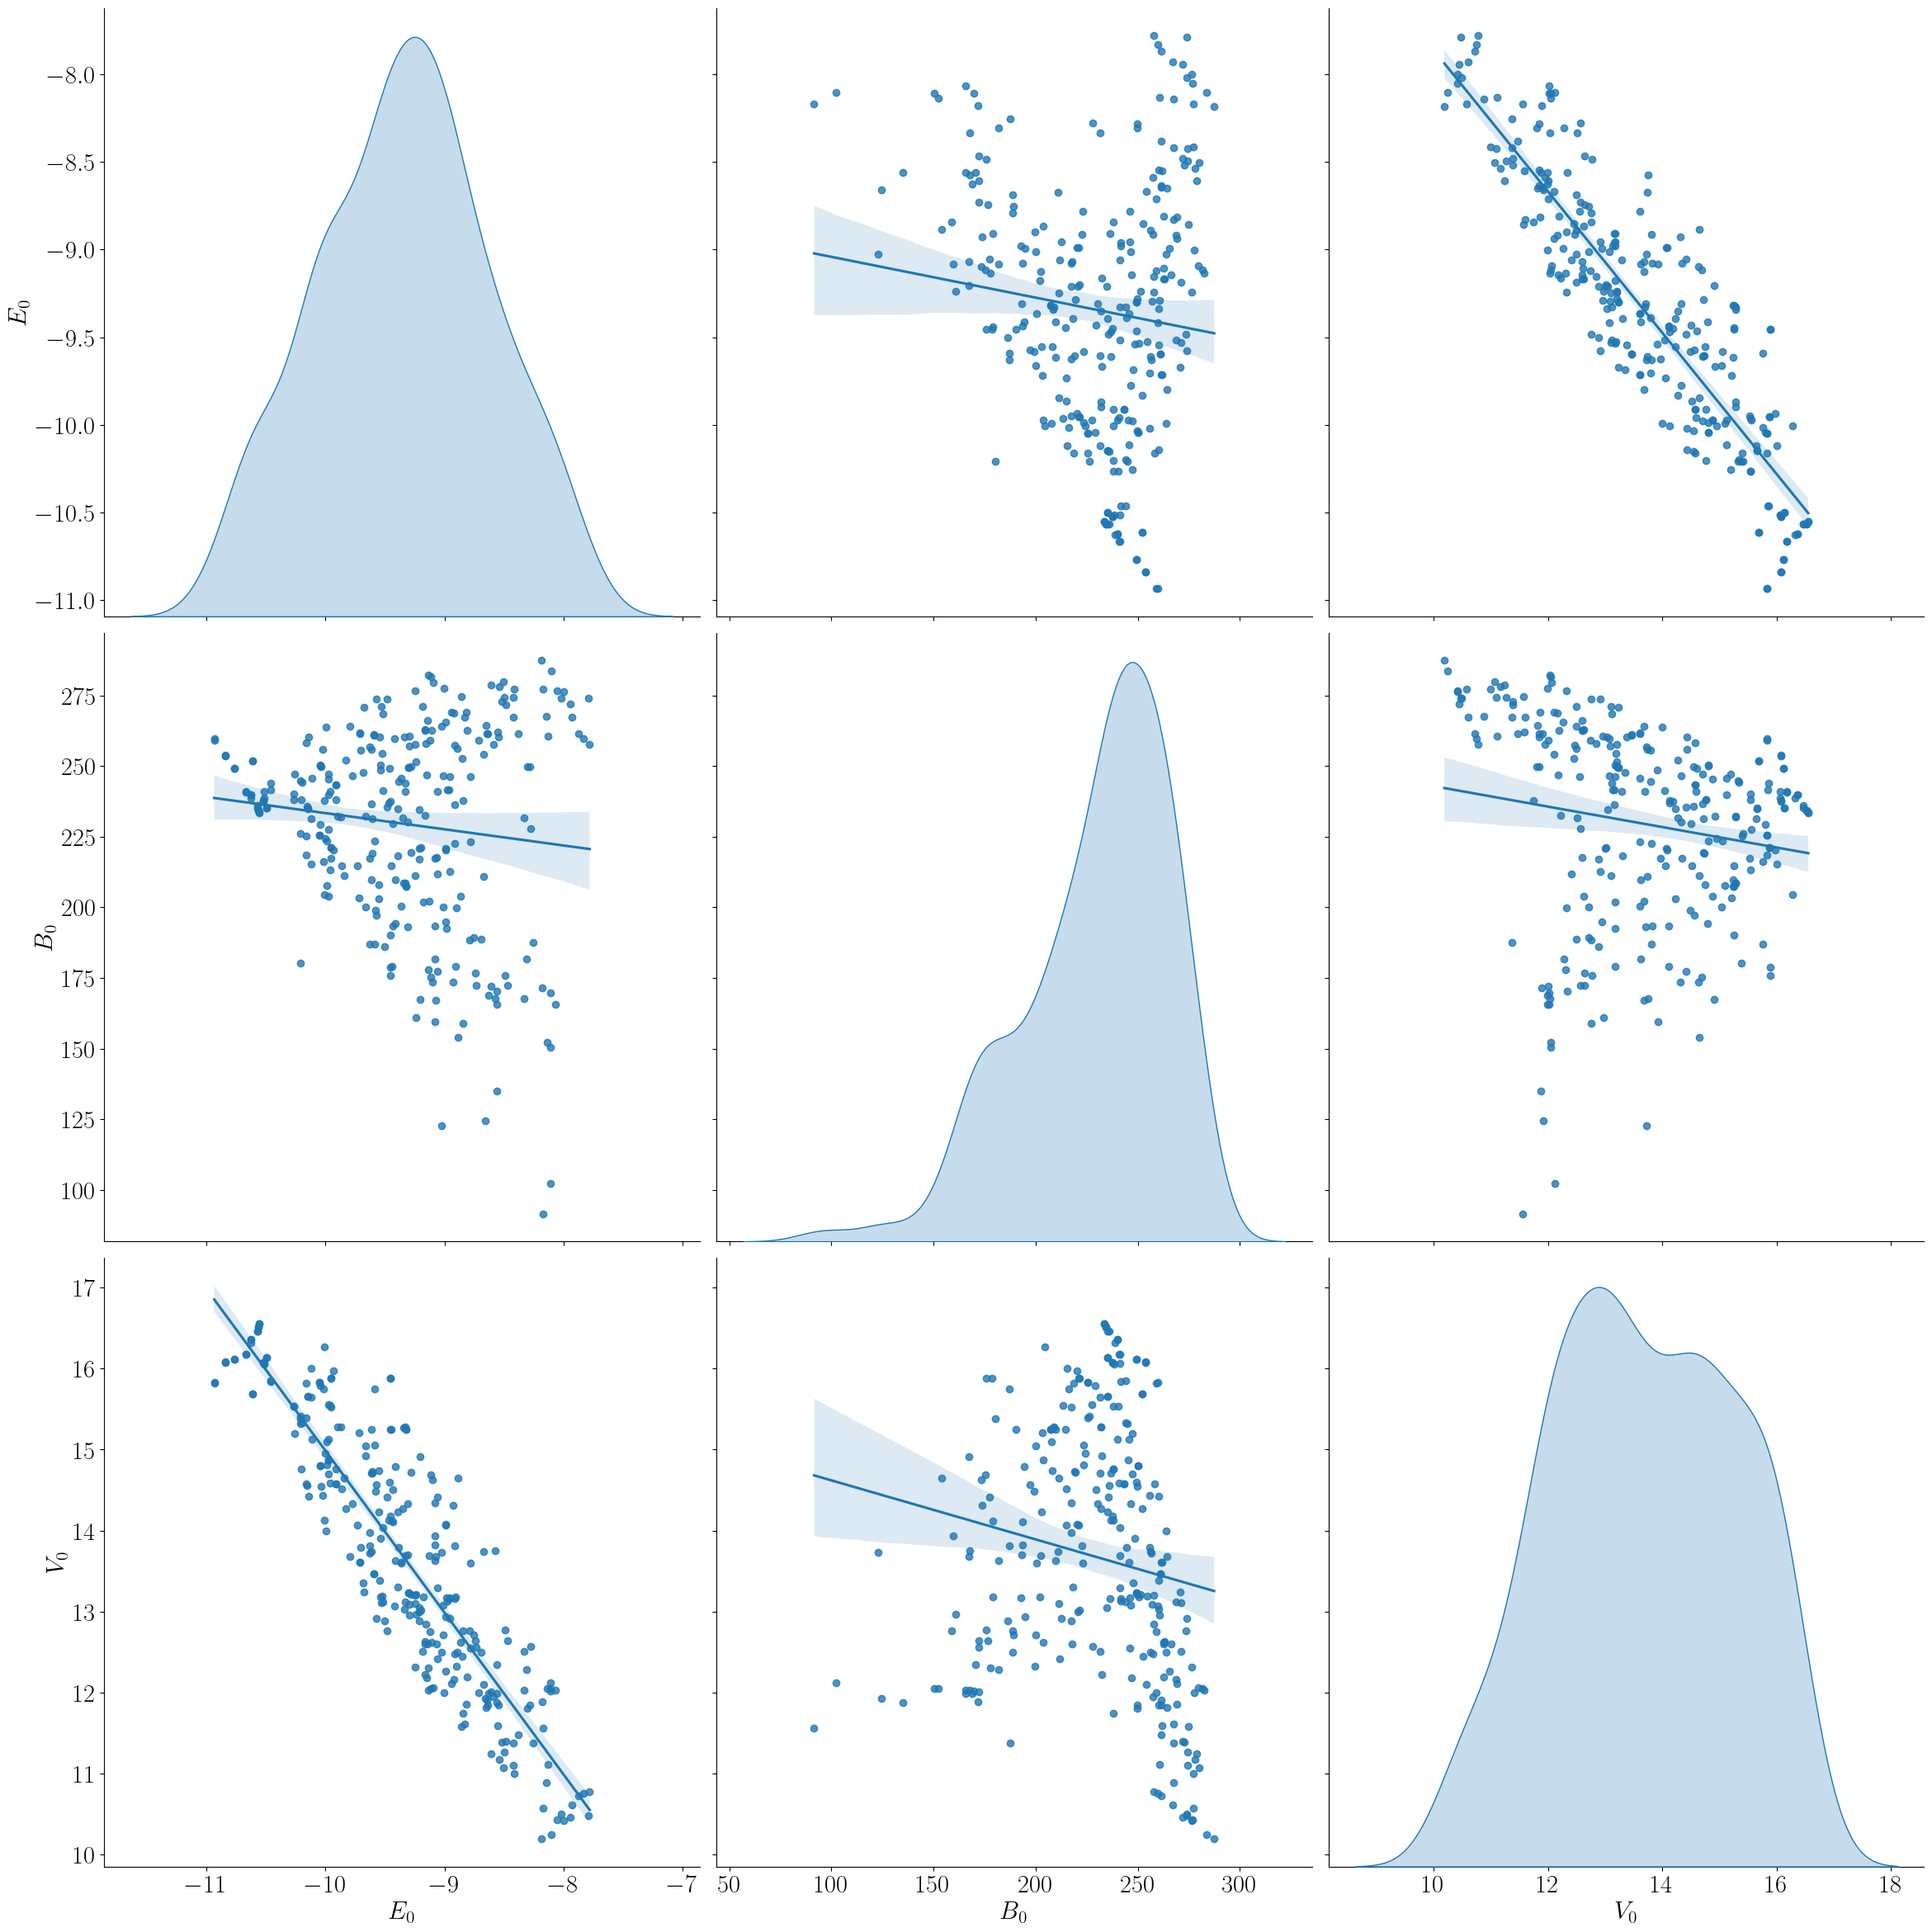

In [26]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# convex hulls ?

In [33]:
import pandas as pd
from scipy.spatial import ConvexHull, convex_hull_plot_2d

In [228]:
components

['Fe', 'Mo']

In [301]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [299]:
PhaseBS = {}
verts = {}
chulls = {}
phasepoints = {}

for phase in BS.Phase.unique():
    PhaseBS[phase] = BS[BS.Phase == phase]

points = P.get_x_ef_points(PhaseBS, components)

In [302]:
chulls = P.get_convex_hulls(PhaseBS, components, return_points = False)

In [303]:
chulls.keys()

dict_keys(['A15', 'C14', 'chi', 'C36', 'sigma', 'hcp', 'mu', 'fcc', 'C15', 'bcc', 'R'])

Text(0.5, 0, '$x_{Fe}$')

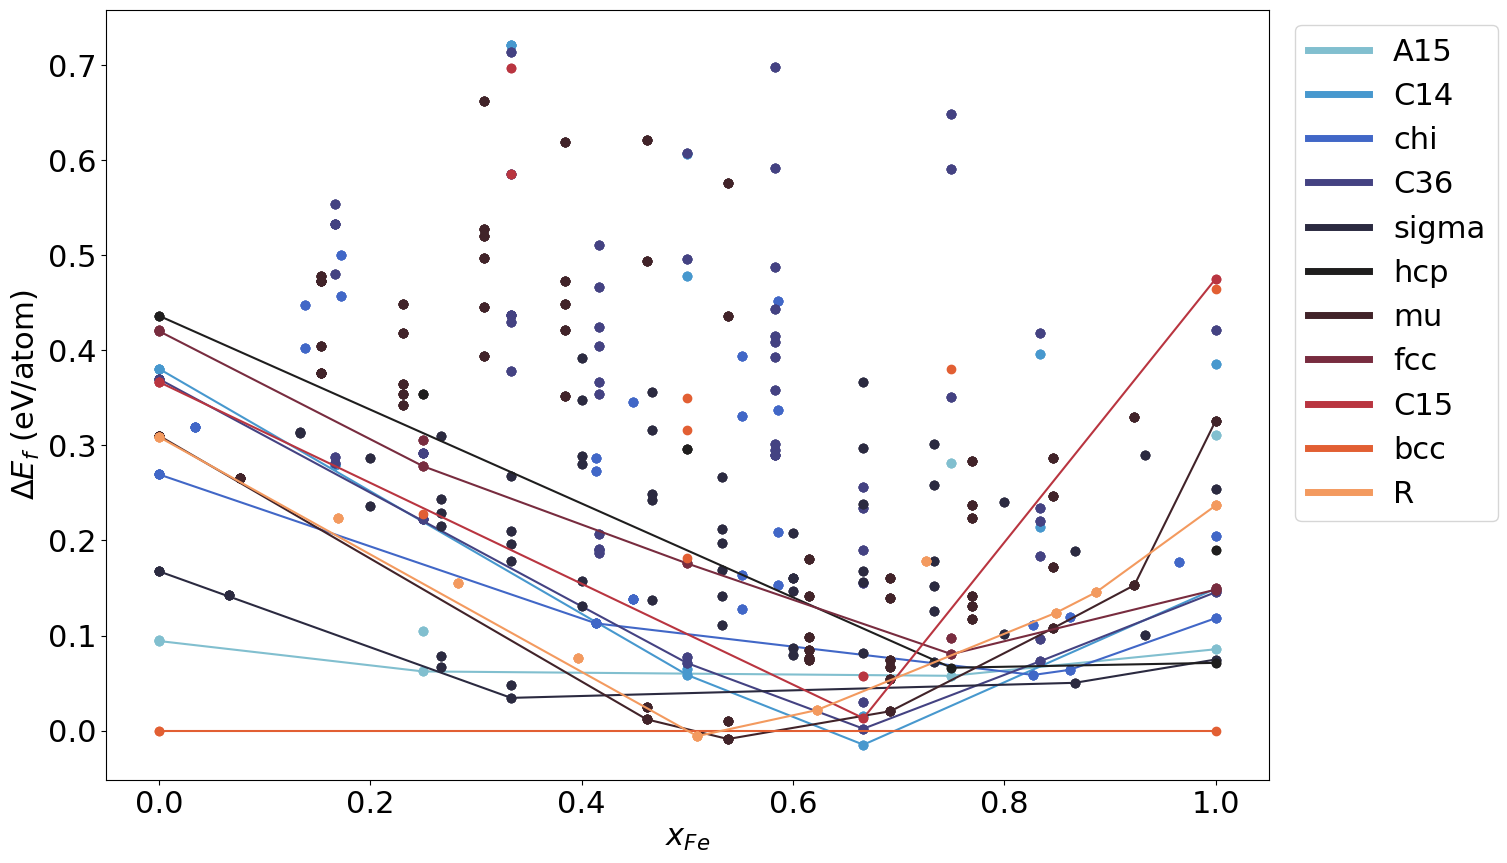

In [320]:
pallette = sns.color_palette("icefire", n_colors=len(PhaseBS))
colors = {phase: color for phase, color in zip(PhaseBS.keys(), pallette)}
fig, ax = plt.subplots()
labels=[]
handles = []
for phase, chull in chulls.items():
    if phase not in irrelevant:
        for visible_facet in chull.simplices[chull.good]:
            ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
            l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase])
        handles.append(l[0])
        labels.append(phase)
leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1))
setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
ax.set_xlabel(rf'$x_{{{components[0]}}}$')

(-0.1, 0.8)

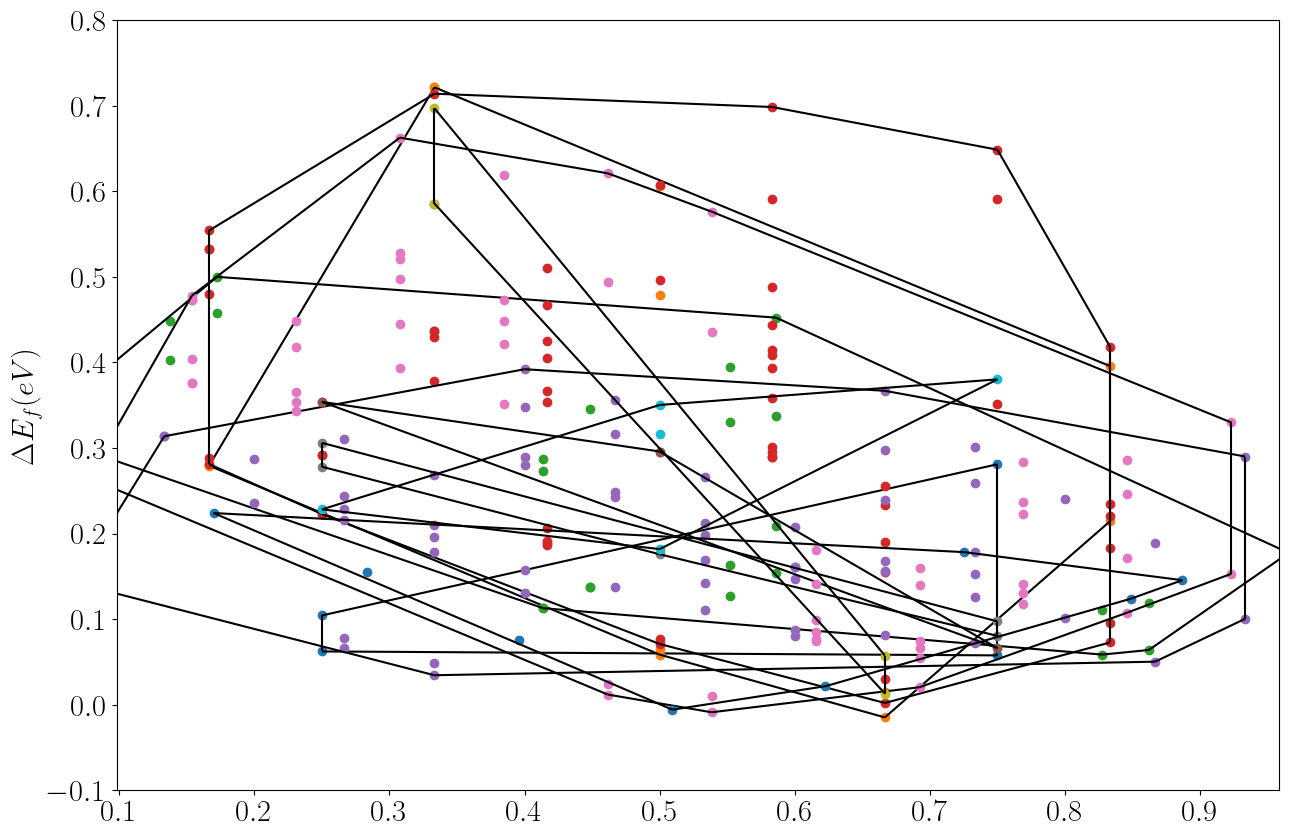

In [73]:
fig, ax = plt.subplots()
for phase, chull in chulls.items():
#    if phase not in irrelevant:
    _ = convex_hull_plot_2d(chull, ax=ax, )
ax.set_ylabel(r'$\Delta E_f (eV)$')
ax.set_ylim([-0.1,0.8])

In [38]:
PhaseBS['C36'].sort_values(by='Fe_pv')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
Mo_sv24.C36.NM,bulk C36,16.516438 A,-10.564355,234.479420 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,24,0,0,24.0,0.000000,1.000000,0.369928,C36
Mo_sv24.C36.FM,bulk C36.FM,16.516879 A,-10.564354,234.383569 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,24,0,0,24.0,0.000000,1.000000,0.369929,C36
Fe_pv4Mo_sv20.C36-ABBBB.NM,bulk C36-ABBBB,15.973885 A,-9.933449,220.307395 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,4,20,0,24.0,0.166667,0.833333,0.554336,C36
Fe_pv4Mo_sv20.C36-BBABB.NM,bulk C36-BBABB,15.332601 A,-10.199552,244.204522 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,4,20,0,24.0,0.166667,0.833333,0.288233,C36
Fe_pv4Mo_sv20.C36-BBABB.FM,bulk C36-BBABB.FM,15.414624 A,-10.206763,226.226871 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,4,20,0,24.0,0.166667,0.833333,0.281022,C36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv20Mo_sv4.C36-ABAAA.FM,bulk C36-ABAAA.FM,11.993054 A,-8.629109,168.873004 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,20,4,0,24.0,0.833333,0.166667,0.072683,C36
Fe_pv20Mo_sv4.C36-BAAAA.NM,bulk C36-BAAAA,11.392767 A,-8.481486,271.876844 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,20,4,0,24.0,0.833333,0.166667,0.220306,C36
Fe_pv20Mo_sv4.C36-AABAA.NM,bulk C36-AABAA,11.847523 A,-8.283533,249.919671 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,20,4,0,24.0,0.833333,0.166667,0.418259,C36
Fe_pv24.C36.NM,bulk C36,10.755719 A,-7.833540,259.756807 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,24,0,0,24.0,1.000000,0.000000,0.421754,C36


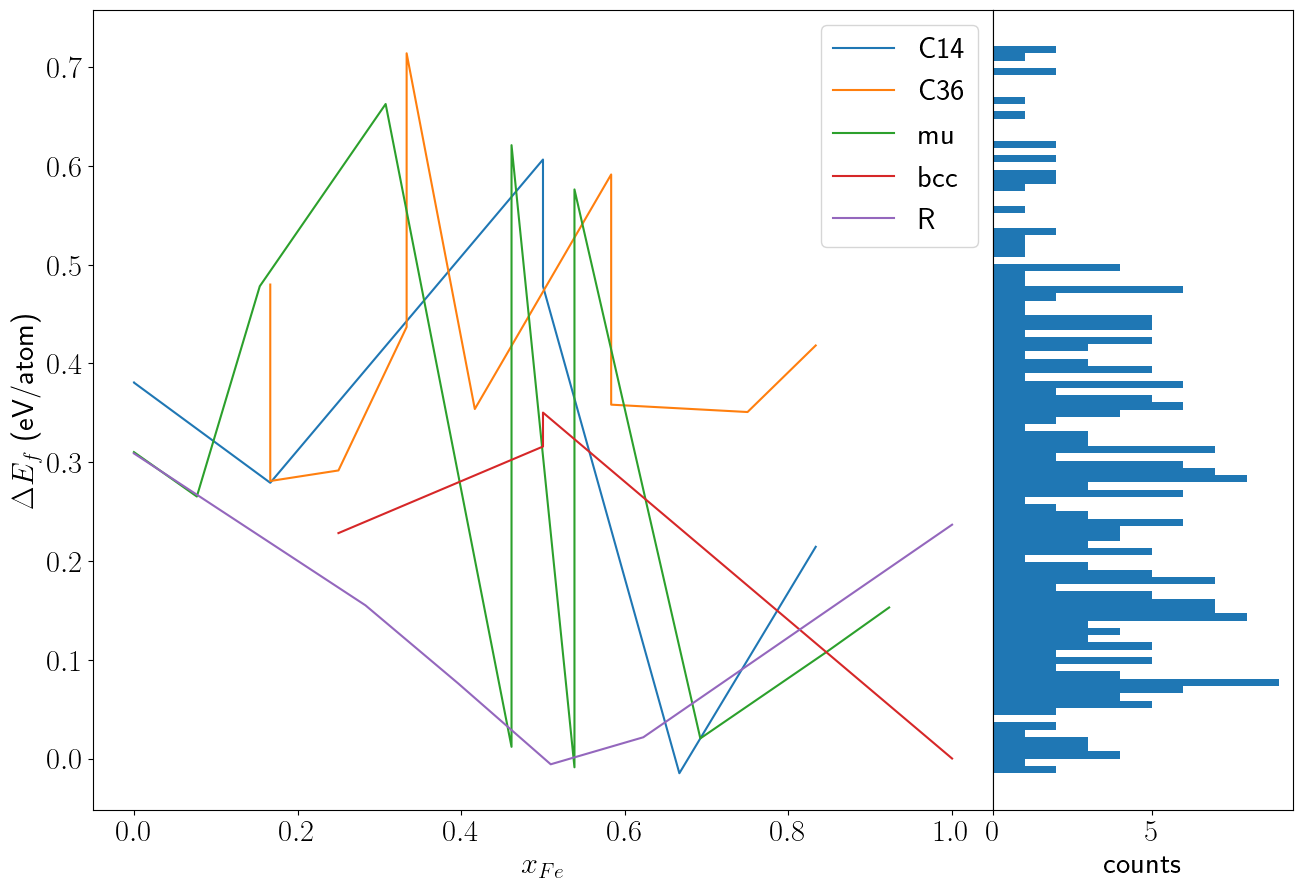

In [39]:
fig = plt.figure()
ax = fig.add_axes([0.2,0.2,0.6,0.8])
for phase, vertices in verts.items():
    if phase not in irrelevant:
        x = PhaseBS[phase].filter(regex=components[0]).iloc[vertices].values.ravel()
        y = PhaseBS[phase]['EF'][vertices].values
        sorter = x.argsort()
        ax.plot(x[sorter], y[sorter], label=phase)
ax2 = fig.add_axes([0.8, 0.2, 0.2, 0.8], sharey=ax)
ax2.hist(BS['EF'], bins=100, orientation='horizontal')
ax2.set_xlabel('counts')
ax2.yaxis.set_visible(False)
ax.set_xlabel(fr'$x_{{{components[0]}}}$')
ax.set_ylabel('$\Delta E_f$ (eV/atom)')
ax.legend()

In [35]:
BS.to_pickle(os.path.join(dataset, f'FurtherCuratedParsedBriefSummary.pkl'))